Use the simulation data to compare the optimizer and input signals
1. Optimizer: LS, GA, PSO, L-BFGS, CMA-ES. 
2. Excitation: Steady-state, step response, noise injection. 

Part of the code are based on course material from the
PhD course: Artificial Intelligence and Advanced Data Analytics for Power Electronics, 
2024, Huai Wang, Shuai zhao. 
Link: https://www.energy.aau.dk/artificial-intelligence-and-advanced-data-analytics-for-power-electronics-2023-e57710

In [1]:
from numba import njit
from SALib.sample import saltelli
from scipy.signal import sawtooth
from SALib.sample import saltelli
from SALib.analyze import sobol

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
import cma, time
from scipy.optimize import least_squares
from scipy.optimize import minimize

import torch, random, numpy as np

ModuleNotFoundError: No module named 'numba'

## Compare optimizers


In [ ]:

# Replace the file address
file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
  

      t         i          v  s  vcarrier         d
0  0.05  7.257854  22.825332  0     0.996  0.755269
1  0.05  7.253641  22.824924  0     0.992  0.755269
2  0.05  7.249429  22.824515  0     0.988  0.755269
3  0.05  7.245216  22.824106  0     0.984  0.755269
4  0.05  7.241004  22.823697  0     0.980  0.755269


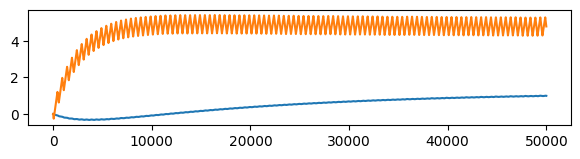

C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_2348\1875209536.py:246: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp),



=== Summary (3 runs) ===
GA      : mean loss=6.2649e-04, mean error=2.8022e+01, mean variance=8.5566e+00, mean epoches=2.2641e-02, mean time=19.75s
PSO     : mean loss=1.0761e-02, mean error=5.5741e+01, mean variance=2.7134e+01, mean epoches=1.7610e-02, mean time=14.66s
CMA-ES  : mean loss=2.7707e-08, mean error=1.3920e+00, mean variance=1.0181e-08, mean epoches=nan, mean time=5.63s
L-BFGS-B: mean loss=2.7718e-08, mean error=1.3574e+00, mean variance=0.0000e+00, mean epoches=1.7846e-02, mean time=2.89s
LeastSq : mean loss=2.7707e-08, mean error=1.3928e+00, mean variance=0.0000e+00, mean epoches=1.6806e-01, mean time=0.50s


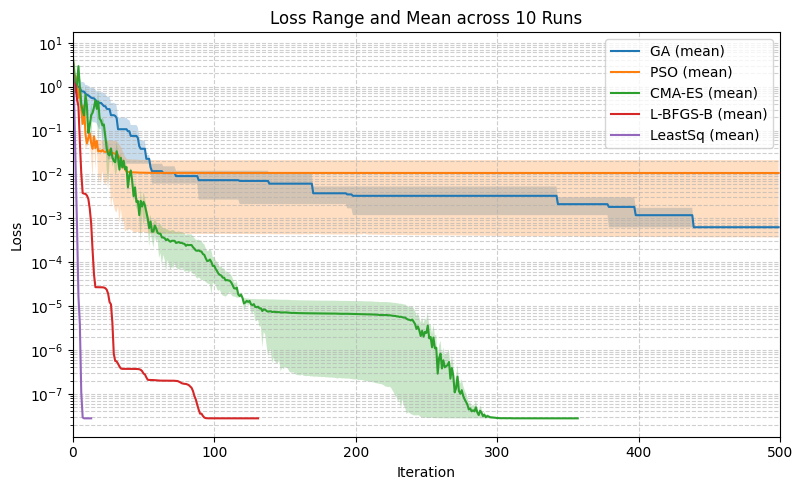

C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_2348\1875209536.py:392: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=[n for n, _ in algos], patch_artist=True)
C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_2348\1875209536.py:392: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=[n for n, _ in algos], patch_artist=True)
C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_2348\1875209536.py:392: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=[n for n, _ in algos], patch_artist=True)
C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_2348\1875209536.py:392

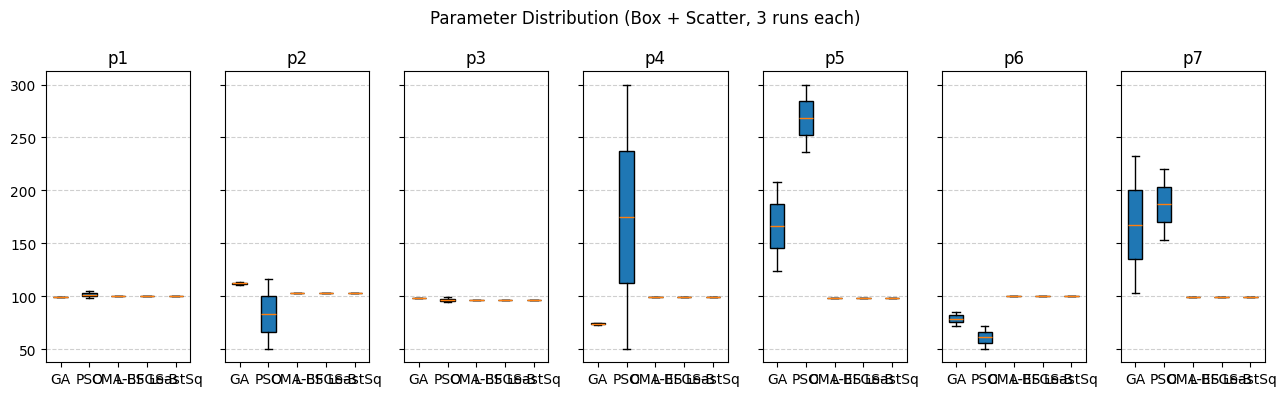

In [ ]:
n_repeat = 2 # Repeat times

# 1. Load data (with a load step input)
# File path of the simulation file (as the real)
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    file_path = "J3_20250918_v22.csv"
    maxiteration = 500

    dt = 1e-7
    # t = np.arange(0, 0.015, dt)
    t = np.arange(0, 0.005, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000

    # Read cvs
    df = pd.read_csv(file_path0+file_path, header=None, skiprows=1)
    df.columns = ["t","i","v", "s","vcarrier","d"]
    print(df.head())

    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    dutytemp = np.array(df['d']) 

        
    plt.figure(figsize=[7,1.5])
    plt.plot(target_waveform)
    plt.plot(target_waveform_current)
    plt.show()

# 2. Define the physics model, using @njit to accelerate RK4 circuit simulation. 
# Part of the code are based on course material from 
# PhD course: Artificial Intelligence and Advanced Data Analytics for Power Electronics
# 2024, Huai Wang, Shuai zhao. 
# Link: https://www.energy.aau.dk/artificial-intelligence-and-advanced-data-analytics-for-power-electronics-2023-e57710
@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                 Kp, Ki, t, yt, loadD1, dutytemp, xiv0):
    L  = 0.6e-3 * Lratio
    C  = 1440e-6 * Cratio
    Rc = 0.03 * RCratio
    Rl = 0.2 * Rlratio
    Ron = 0.05 * Rdsonratio
    Vd  = 1.0 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = 2.0 * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    # Initialize
    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  # On-state, S = 1.
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))
    # else:        # Off-state, S = 0.
    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    # ---------- Loop through simulation steps ----------
    for i in range(N):
        # Duty ratio update at the peak of the sawtooth.
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  # Determine the switching state

        #--------- Calculate matrix A and B ---------
        if si == 1:  # On-state
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:        # Off-state
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        # CCM, to avoid the inductor current goes to zero. 
        if Il < 0:
            Il = 0.0
        
        # Save the output voltage. 
        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

# 3. Define loss function and optimizer
if 1==1:
    # -----------------------------
    # Common fitness/loss function
    # -----------------------------
    def fitness(params, target_waveform, target_waveform_current, dutytemp):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        loss = np.mean((result_slice - target_waveform)**2) + \
            1*np.mean((result_slice_current - target_waveform_current)**2)
        return loss


    # -----------------------------
    # GA genetic algorithm
    # -----------------------------
    def run_ga(target_waveform, target_waveform_current, dutytemp,
            pop_size=30, n_gen=maxiteration):
        dim = 7
        low, high = 0.5, 3
        pop = np.random.uniform(low, high, (pop_size, dim))
        best_hist = []
        for _ in range(n_gen):
            fitness_vals = np.array([fitness(ind, target_waveform, target_waveform_current, dutytemp) for ind in pop])
            best_hist.append(np.min(fitness_vals))
            parents = pop[np.argsort(fitness_vals)[:pop_size//2]]
            offspring = parents + np.random.normal(0, 0.05, parents.shape)
            offspring = np.clip(offspring, low, high)
            pop = np.vstack([parents, offspring])
        return pop[np.argmin(fitness_vals)], best_hist

    # -----------------------------
    # PSO
    # -----------------------------
    def run_pso(target_waveform, target_waveform_current, dutytemp,
                n_particles=20, n_iter=maxiteration):
        dim = 7
        bounds_low, bounds_high = 0.5, 3
        pos = np.random.uniform(bounds_low, bounds_high, (n_particles, dim))
        vel = np.zeros_like(pos)
        pbest, pbest_val = pos.copy(), np.full(n_particles, np.inf)
        gbest = pos[0].copy()
        best_hist = []
        for _ in range(n_iter):
            vals = np.array([fitness(p, target_waveform, target_waveform_current, dutytemp) for p in pos])
            improved = vals < pbest_val
            pbest[improved], pbest_val[improved] = pos[improved], vals[improved]
            if vals.min() < fitness(gbest, target_waveform, target_waveform_current, dutytemp):
                gbest = pos[np.argmin(vals)]
            best_hist.append(vals.min())

            # Update velocity and position
            r1, r2 = np.random.rand(*pos.shape), np.random.rand(*pos.shape)
            vel = 0.7*vel + 1.5*r1*(pbest - pos) + 1.5*r2*(gbest - pos)
            pos = np.clip(pos + vel, bounds_low, bounds_high)
        return gbest, best_hist

    # -----------------------------
    # CMA-ES
    # -----------------------------
    def run_cma(target_waveform, target_waveform_current, dutytemp, max_iter=maxiteration):
        x0 = np.ones(7)+0.3
        es = cma.CMAEvolutionStrategy(x0, 0.3, {'bounds':[0.5,3], 'maxiter':max_iter, 'verb_disp':0})
        best_hist = []
        while not es.stop():
            sols = es.ask()
            vals = [fitness(x, target_waveform, target_waveform_current, dutytemp) for x in sols]
            es.tell(sols, vals)
            best_hist.append(np.min(vals))
        return es.result.xbest, best_hist

    # -----------------------------
    # Differential Evolution (DE)
    # -----------------------------
    def run_de(target_waveform, target_waveform_current, dutytemp, max_iter=maxiteration):
        bounds = [(0.5,3)]*7
        result = differential_evolution(
            lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp),
            bounds, maxiter=max_iter, disp=False)
        best_hist = np.linspace(result.fun*2, result.fun, max_iter)
        return result.x, best_hist

    def run_lbfgs(target_waveform, target_waveform_current, dutytemp, max_iter=maxiteration):
        x0 = np.ones(7)+0.3
        bounds = [(0.5, 3)] * 7
        hist = []

        def callback(xk):
            val = fitness(xk, target_waveform, target_waveform_current, dutytemp)
            hist.append(val)

        res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp),
                    x0,
                    method="L-BFGS-B",
                    bounds=bounds,
                    options={"maxiter": max_iter, 
                                "disp": True,
                                'gtol': 1e-25 ,  # Gradient tolerance
                                'ftol': 1e-25    # Function tolerance
                        },
                    callback=callback)

        if not hist:  
            hist.append(res.fun)
        return res.x, hist

    # -----------------------------
    # Least Squares
    # -----------------------------
    def residuals(params, target_waveform, target_waveform_current, dutytemp):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        res_voltage = result_slice - target_waveform
        res_current = 1 * (result_slice_current - target_waveform_current)
        return np.concatenate([res_voltage, res_current])

    def run_leastsq(target_waveform, target_waveform_current, dutytemp, max_iter=maxiteration):
        x0 = np.ones(7) + 0.7
        # x0 = np.array([0.5, 0.6, 0.55, 3, 2.1, 1.1,2])
        bounds = (0.5*np.ones(7), 3*np.ones(7))
        hist = []

        def loss_fun(x):
            # Compute comparable scalar loss (MSE style)
            return fitness(x, target_waveform, target_waveform_current, dutytemp)

        def callback(xk, *args, **kwargs):
            # hist.append(loss_fun(xk)**0.5)
            hist.append(loss_fun(xk))
            # hist.append(loss_fun(xk)) # The loss goes to 1e-23, which is different from the others

        res = least_squares(
            residuals,  # returns vector of residuals
            x0,
            args=(target_waveform, target_waveform_current, dutytemp),
            bounds=bounds,
            max_nfev=max_iter,
            verbose=0,
            callback=callback
        )

        if not hist:  # In case callback didn’t run
            hist.append(loss_fun(res.x))
            # hist.append(loss_fun(res.fun))
        return res.x, hist


    theta_ref = np.array([1,1,1,1,1,1,1])  # reference values    
    def compare_algorithms(target_waveform, target_waveform_current, dutytemp):
        algos = [
            ("GA", run_ga),
            ("PSO", run_pso),
            ("CMA-ES", run_cma),
            ("L-BFGS-B", run_lbfgs),
            ("LeastSq", run_leastsq)
        ]

        all_results = {}
        for name, func in algos:
            all_params, all_hist, all_time = [], [], []
            for n_repeat_counter in range(n_repeat):
                random.seed(n_repeat_counter)
                start = time.time()
                params, hist = func(target_waveform, target_waveform_current, dutytemp)
                elapsed = time.time() - start
                all_params.append(params)
                all_hist.append(hist)
                all_time.append(elapsed)

            # Pad histories for averaging
            max_len = max(len(h) for h in all_hist)
            loss_mat = np.full((n_repeat, max_len), np.nan)
            for i, h in enumerate(all_hist):
                loss_mat[i, :len(h)] = h

            all_results[name] = {
                "params": np.array(all_params),
                "losses": loss_mat,
                "times": np.array(all_time)
            }

        # ---- Summary ----
        print("\n=== Summary (3 runs) ===")
        for name, res in all_results.items():
            #     final_losses = [h[~np.isnan(h)][-1] for h in res["losses"]]
            #     print(f"{name:8s}: mean loss={np.mean(final_losses):.4e}, mean time={np.mean(res['times']):.2f}s")

            # for name, res in all_results.items():
            final_losses = [h[~np.isnan(h)][-1] for h in res["losses"]]
            # print(f"{name:8s}: mean loss={np.mean(final_losses):.4e}, mean time={np.mean(res['times']):.2f}s")
            reference = np.ones(7)
            # print()
            errors = np.abs(np.mean(all_results[name]['params'],0)- reference)*100
            variance = np.mean(np.var(all_results[name]['params'],0))*100
            np.mean(errors)
            epoches_to_converge = np.mean(all_results[name]['losses'])/n_repeat
            print(f"{name:8s}: mean loss={np.mean(final_losses):.4e}, mean error={np.mean(errors):.4e}, mean variance={np.mean(variance):.4e}, mean epoches={np.mean(epoches_to_converge):.4e}, mean time={np.mean(res['times']):.2f}s")
        

        # ---- Plot mean ± range losses ----
        plt.figure(figsize=(8,5))
        for name, res in all_results.items():
            losses = res["losses"]
            mean_loss = np.nanmean(losses, axis=0)
            min_loss = np.nanmin(losses, axis=0)
            max_loss = np.nanmax(losses, axis=0)
            iterations = np.arange(len(mean_loss))

            plt.fill_between(iterations, min_loss, max_loss, alpha=0.25)
            plt.plot(iterations, mean_loss, label=f"{name} (mean)")

        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.yscale("log")
        plt.title("Loss Range and Mean across 10 Runs")
        plt.grid(True, which='both', linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.xlim([0,500])
        plt.show()

        # ---- boxplot + scatter ----
        # LeastSq
        # param_names = [f"p{i+1}" for i in range(all_results['CMA-ES']['params'].shape[1])]
        param_names = [f"p{i+1}" for i in range(all_results['LeastSq']['params'].shape[1])]
        fig, axes = plt.subplots(1, len(param_names), figsize=(13, 4), sharey=True)

        for i, pname in enumerate(param_names):
            # data = [all_results[name]["params"][:, i] for name, _ in algos]
            data = [100 * all_results[name]["params"][:, i] / theta_ref[i] for name, _ in algos]
            axes[i].boxplot(data, labels=[n for n, _ in algos], patch_artist=True)
            # Add scatter
            # for j, vals in enumerate(data):
            #     x = np.random.normal(j + 1, 0.04, size=len(vals))
            #     axes[i].scatter(x, vals, alpha=0.6, s=15)
            axes[i].set_title(pname)
            axes[i].grid(True, axis='y', linestyle='--', alpha=0.6)

        fig.suptitle("Parameter Distribution (Box + Scatter, 3 runs each)")
        plt.tight_layout()
        plt.show()

        return all_results

# 4. Run the optimizers until convergence. 
results = compare_algorithms(target_waveform, target_waveform_current, dutytemp)



## Compare the input signals.

In [ ]:

# Only enable the last three optimizers

if 1==1:
    # -----------------------------
    # Common fitness
    # -----------------------------
    def fitness(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        loss = np.mean((result_slice - target_waveform)**2) + \
            1*np.mean((result_slice_current - target_waveform_current)**2)
        return loss


    # -----------------------------
    # Simplified GA
    # -----------------------------
    def run_ga(target_waveform, target_waveform_current, dutytemp, S1,
            pop_size=30, n_gen=maxiteration):
        dim = 7
        low, high = 0.5, 3
        pop = np.random.uniform(low, high, (pop_size, dim))
        best_hist = []
        for _ in range(n_gen):
            fitness_vals = np.array([fitness(ind, target_waveform, target_waveform_current, dutytemp, S1) for ind in pop])
            best_hist.append(np.min(fitness_vals))
            parents = pop[np.argsort(fitness_vals)[:pop_size//2]]
            offspring = parents + np.random.normal(0, 0.05, parents.shape)
            offspring = np.clip(offspring, low, high)
            pop = np.vstack([parents, offspring])
        return pop[np.argmin(fitness_vals)], best_hist

    # -----------------------------
    # PSO
    # -----------------------------
    def run_pso(target_waveform, target_waveform_current, dutytemp, S1,
                n_particles=20, n_iter=maxiteration):
        dim = 7
        bounds_low, bounds_high = 0.5, 3
        pos = np.random.uniform(bounds_low, bounds_high, (n_particles, dim))
        vel = np.zeros_like(pos)
        pbest, pbest_val = pos.copy(), np.full(n_particles, np.inf)
        gbest = pos[0].copy()
        best_hist = []
        for _ in range(n_iter):
            vals = np.array([fitness(p, target_waveform, target_waveform_current, dutytemp, S1) for p in pos])
            improved = vals < pbest_val
            pbest[improved], pbest_val[improved] = pos[improved], vals[improved]
            if vals.min() < fitness(gbest, target_waveform, target_waveform_current, dutytemp, S1):
                gbest = pos[np.argmin(vals)]
            best_hist.append(vals.min())

            # Update velocity and position
            r1, r2 = np.random.rand(*pos.shape), np.random.rand(*pos.shape)
            vel = 0.7*vel + 1.5*r1*(pbest - pos) + 1.5*r2*(gbest - pos)
            pos = np.clip(pos + vel, bounds_low, bounds_high)
        return gbest, best_hist

    # -----------------------------
    # CMA-ES
    # -----------------------------
    def run_cma(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7)+0.3
        es = cma.CMAEvolutionStrategy(x0, 0.3, {'bounds':[0.5,3], 'maxiter':max_iter, 'verb_disp':0})
        best_hist = []
        while not es.stop():
            sols = es.ask()
            vals = [fitness(x, target_waveform, target_waveform_current, dutytemp, S1) for x in sols]
            es.tell(sols, vals)
            best_hist.append(np.min(vals))
        return es.result.xbest, best_hist

    # -----------------------------
    # Differential Evolution (DE)
    # -----------------------------
    def run_de(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        bounds = [(0.5,3)]*7
        result = differential_evolution(
            lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
            bounds, maxiter=max_iter, disp=False)
        best_hist = np.linspace(result.fun*2, result.fun, max_iter)
        return result.x, best_hist

    def run_lbfgs(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        # Initial estimations
        x0 = np.ones(7)+0.3
        bounds = [(0.5, 3)] * 7
        hist = []

        # Record loss in each iteration
        def callback(xk):
            val = fitness(xk, target_waveform, target_waveform_current, dutytemp, S1)
            hist.append(val)

        res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
                    x0,
                    method="L-BFGS-B",
                    bounds=bounds,
                    options={"maxiter": max_iter, 
                                "disp": True,
                                'gtol': 1e-25 ,  # Gradient tolerance
                                'ftol': 1e-25    # Function tolerance
                        },
                    callback=callback)

        if not hist:  # Avoid no callback
            hist.append(res.fun)
        return res.x, hist

    # -----------------------------
    # Least Squares
    # -----------------------------
    def residuals(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        # Voltage and current prediction errors
        res_voltage = result_slice - target_waveform
        res_current = 1 * (result_slice_current - target_waveform_current)
        return np.concatenate([res_voltage, res_current])

    def run_leastsq(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7) + 0.7
        # x0 = np.array([0.5, 0.6, 0.55, 3, 2.1, 1.1,2])
        bounds = (0.5*np.ones(7), 3*np.ones(7))
        hist = []

        def loss_fun(x):
            # Compute comparable scalar loss (MSE style)
            return fitness(x, target_waveform, target_waveform_current, dutytemp, S1)

        def callback(xk, *args, **kwargs):
            # hist.append(loss_fun(xk)**0.5)
            hist.append(loss_fun(xk))
            # hist.append(loss_fun(xk)) # The loss goes to 1e-23, which is different from the others

        res = least_squares(
            residuals,  # returns vector of residuals
            x0,
            args=(target_waveform, target_waveform_current, dutytemp, S1),
            bounds=bounds,
            max_nfev=max_iter,
            verbose=0,
            callback=callback
        )

        if not hist:  # In case callback didn’t run
            hist.append(loss_fun(res.x))
            # hist.append(loss_fun(res.fun))
        return res.x, hist

def compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1):
    results = {}
    # for name, func in [("GA", run_ga), ("PSO", run_pso), ("CMA-ES", run_cma), ("DE", run_de)]:
    for name, func in [
                    # ("GA", run_ga), 
                    # ("PSO", run_pso), 
                    ("CMA-ES", run_cma), 
                    ("L-BFGS-B", run_lbfgs),
                    ("LeastSq", run_leastsq) 
                    ]:
    # for name, func in [ ("L-BFGS-B", run_lbfgs)]:
        start = time.time()
        params, hist = func(target_waveform, target_waveform_current, dutytemp, S1)
        elapsed = time.time() - start
        results[name] = (params, hist, elapsed)
    #    print(name,results[name])

    # Plot the convergence curve
    # plt.figure(figsize=(8,5))
    plt.figure(figsize=[7,4])
    for name, (_, hist, _) in results.items():
        plt.plot(hist, label=name)
    plt.xlabel("Iteration")
    plt.ylabel("Best loss")
    plt.title("Algorithm Comparison: Convergence Curves")
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.show()

    # Print estimations
    print("\n=== Final Comparison ===")
    for name, (params, hist, elapsed) in results.items():
        print(f"{name:6s}: final loss={hist[-1]:.4e}, time={elapsed:.2f}s, params={params}")

    # Plot bar chart
    param_data = {name: params for name, (params, _, _) in results.items()}
    param_names = [f"p{i+1}" for i in range(len(next(iter(param_data.values()))))]

    fig, ax = plt.subplots(figsize=(7,4))
    x = np.arange(len(param_names))
    width = 0.15

    for i, (name, params) in enumerate(param_data.items()):
        ax.bar(x + i*width, params, width, label=name)

    ax.set_xticks(x + width*(len(param_data)/2))
    ax.set_xticklabels(param_names)
    ax.set_ylabel("Parameter Value")
    ax.set_title("Parameter Comparison Among Algorithms")
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


      t          i          v  s  vcarrier         d
0  0.05  11.999287  24.000025  0     0.996  0.563854
1  0.05  11.994720  23.999890  0     0.992  0.563854
2  0.05  11.990154  23.999755  0     0.988  0.563854
3  0.05  11.985587  23.999619  0     0.984  0.563854
4  0.05  11.981021  23.999484  0     0.980  0.563854


C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_2348\3829816441.py:102: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),


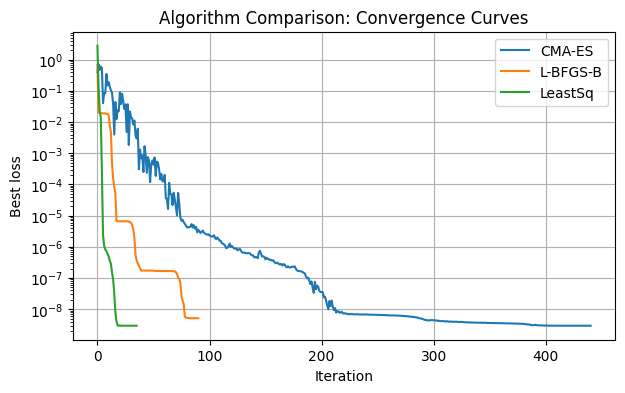


=== Final Comparison ===
CMA-ES: final loss=2.9574e-09, time=6.69s, params=[1.00112716 1.01398701 0.96840957 0.9798256  0.79073711 1.04296229
 0.92889062]
L-BFGS-B: final loss=5.1511e-09, time=2.10s, params=[1.00167284 1.01524489 0.96985129 0.97127138 1.15905149 0.94609972
 1.17616427]
LeastSq: final loss=2.9583e-09, time=1.19s, params=[1.00091117 1.01400655 0.96842879 0.97931889 0.81178261 1.03959299
 0.93105128]


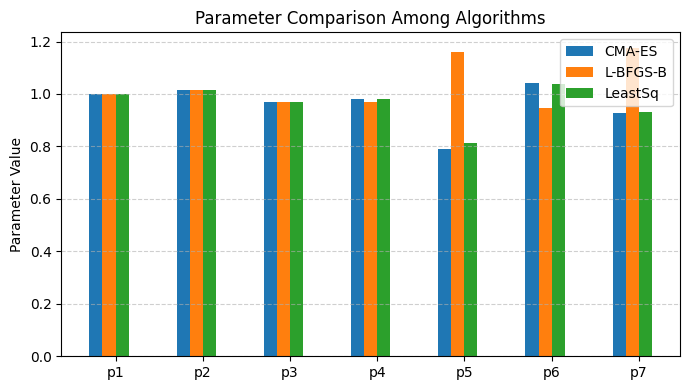

In [ ]:
# Input1 Steady state
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    file_path = "J3_20250918_v22steadystate.csv"
    maxiteration = 500
    dt = 1e-7
    # t = np.arange(0, 0.015, dt)
    t = np.arange(0, 0.005, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000

    df = pd.read_csv(file_path0+file_path, header=None, skiprows=1)
    df.columns = ["t","i","v", "s","vcarrier","d"]
    print(df.head())

    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    dutytemp = np.array(df['d']) 


# The physics model
@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 0.6e-3 * Lratio
    C  = 1440e-6 * Cratio
    Rc = 0.03 * RCratio
    Rl = 0.2 * Rlratio
    Ron = 0.05 * Rdsonratio
    Vd  = 1.0 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = 2.0 * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))
    # else:        
    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    for i in range(N):
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  
        # si = S1[i]

        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:        
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        # CCM
        if Il < 0:
            Il = 0.0

        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)


      t          i          v  s  vcarrier         d
0  0.05  10.663691  23.968423  0     0.996  0.578127
1  0.05  10.659174  23.968199  0     0.992  0.578127
2  0.05  10.654658  23.967975  0     0.988  0.578127
3  0.05  10.650141  23.967751  0     0.984  0.578127
4  0.05  10.645625  23.967526  0     0.980  0.578127


C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_2348\3829816441.py:102: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),


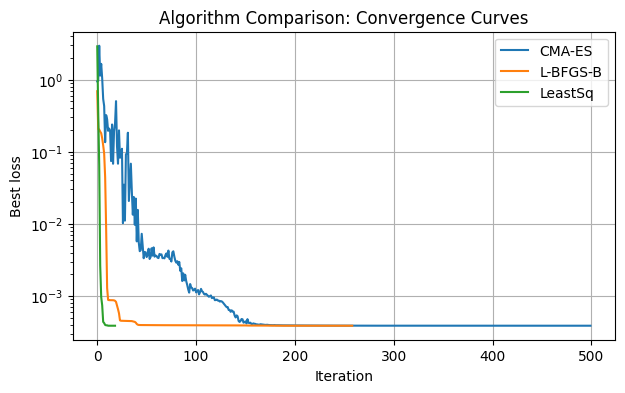


=== Final Comparison ===
CMA-ES: final loss=3.8508e-04, time=8.33s, params=[0.99252727 1.02081103 0.98039063 0.6926424  2.98366234 0.60960233
 1.66283986]
L-BFGS-B: final loss=3.8503e-04, time=6.25s, params=[0.9924397  1.02068513 0.98042052 0.69236067 3.         0.60626647
 1.66851025]
LeastSq: final loss=3.8503e-04, time=0.64s, params=[0.99238154 1.02076635 0.98041248 0.69215945 2.99999982 0.6068365
 1.6653544 ]


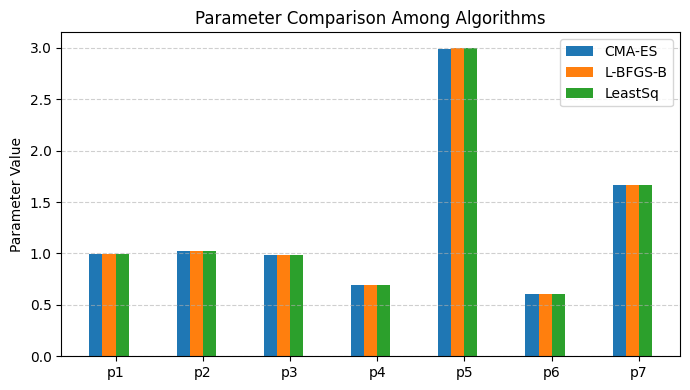

In [ ]:
# Input2 disturbance injection
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    file_path = "J3_20250918_v22noise.csv"
    maxiteration = 500
    dt = 1e-7
    # t = np.arange(0, 0.015, dt)
    t = np.arange(0, 0.005, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000

    df = pd.read_csv(file_path0+file_path, header=None, skiprows=1)
    df.columns = ["t","i","v", "s","vcarrier","d"]
    print(df.head())

    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    dutytemp = np.array(df['d']) 


@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 0.6e-3 * Lratio
    C  = 1440e-6 * Cratio
    Rc = 0.03 * RCratio
    Rl = 0.2 * Rlratio
    Ron = 0.05 * Rdsonratio
    Vd  = 1.0 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = 2.0 * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))
    # else:        
    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    for i in range(N):
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  
        # si = S1[i]

        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:        
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        # CCM
        if Il < 0:
            Il = 0.0

        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)


      t         i          v  s  vcarrier         d
0  0.05  7.257854  22.825332  0     0.996  0.755269
1  0.05  7.253641  22.824924  0     0.992  0.755269
2  0.05  7.249429  22.824515  0     0.988  0.755269
3  0.05  7.245216  22.824106  0     0.984  0.755269
4  0.05  7.241004  22.823697  0     0.980  0.755269


C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_2348\3829816441.py:102: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),


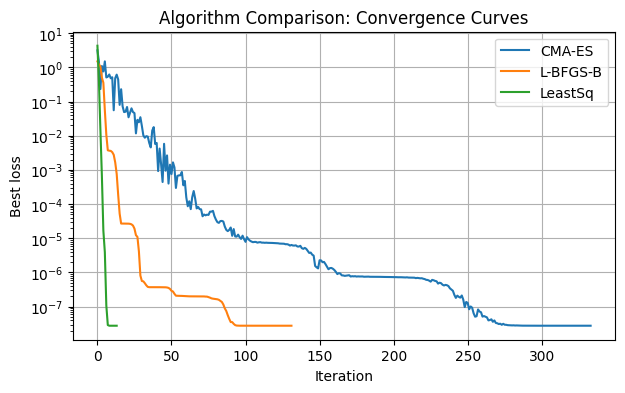


=== Final Comparison ===
CMA-ES: final loss=2.7707e-08, time=5.95s, params=[1.00013489 1.03190478 0.96770256 0.99306126 0.98343755 1.00391625
 0.99429656]
L-BFGS-B: final loss=2.7718e-08, time=2.57s, params=[1.00012452 1.03189233 0.96770233 0.99312814 0.98499556 1.00361077
 0.99478327]
LeastSq: final loss=2.7707e-08, time=0.46s, params=[1.00013502 1.03190499 0.96770254 0.99306088 0.9834158  1.00392089
 0.99428763]


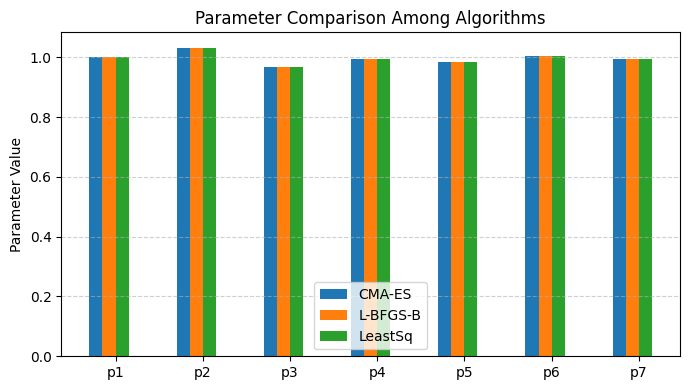

In [ ]:
# Input3 load step response
# Path
if 1==1:
    # file_path0 = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/4_digital_twin/BuckConverter/BuckResult/"
    file_path = "J3_20250918_v22.csv"
    maxiteration = 500
    dt = 1e-7
    # t = np.arange(0, 0.015, dt)
    t = np.arange(0, 0.005, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000

    df = pd.read_csv(file_path0+file_path, header=None, skiprows=1)
    df.columns = ["t","i","v", "s","vcarrier","d"]
    print(df.head())

    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    dutytemp = np.array(df['d']) 


# The 
@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 0.6e-3 * Lratio
    C  = 1440e-6 * Cratio
    Rc = 0.03 * RCratio
    Rl = 0.2 * Rlratio
    Ron = 0.05 * Rdsonratio
    Vd  = 1.0 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = 2.0 * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))
    # else:        
    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    for i in range(N):
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  
        # si = S1[i]

        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:        
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        # CCM
        if Il < 0:
            Il = 0.0

        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

results = compare_algorithms(target_waveform, target_waveform_current, dutytemp,S1)
